In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from random import randint
import torch.nn as nn
from tqdm import tqdm
import umap
from sklearn.manifold import TSNE
import seaborn as sns
import os
from sklearn.metrics.pairwise import cosine_similarity
from collections import defaultdict
import random
from PIL import Image

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3060 Laptop GPU


In [4]:
# Define transform (same as before)
transform = transforms.Compose([
    transforms.Resize(224),  # Standard input size
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load CIFAR-10 test set
test_dataset = torchvision.datasets.CIFAR10(
    root=r'C:\Users\rafin\Desktop\465_Project\CSE465_FeatureUnderstanding\data',
    train=False,
    download=True,
    transform=transform
)

# DataLoader for batching
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

Files already downloaded and verified


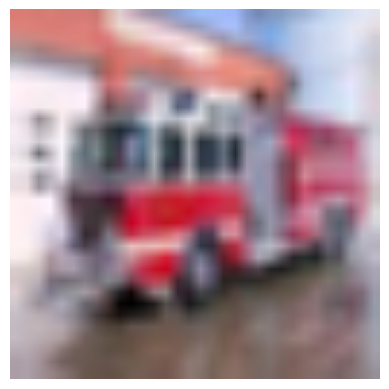

Label: truck


In [3]:
# %%
# Undo normalization for plotting
def imshow(img):
    img = img * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1) + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

# Visual check
images, labels = next(iter(test_loader))
random_image = randint(0, len(images) - 1)
imshow(images[random_image])
print("Label:", test_dataset.classes[labels[random_image]])

In [2]:
# Load pre-trained ZFNet (using AlexNet as base with ZFNet modifications)
class ZFNet(nn.Module):
    def __init__(self, num_classes=1000):
        super(ZFNet, self).__init__()
        self.features = nn.Sequential(
            # Layer 1: 7x7 conv (ZFNet uses 7x7 instead of AlexNet's 11x11)
            nn.Conv2d(3, 96, kernel_size=7, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.LocalResponseNorm(size=5, alpha=0.0001, beta=0.75, k=2),
            
            # Layer 2: 5x5 conv
            nn.Conv2d(96, 256, kernel_size=5, stride=2, padding=0),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.LocalResponseNorm(size=5, alpha=0.0001, beta=0.75, k=2),
            
            # Layer 3: 3x3 conv
            nn.Conv2d(256, 384, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            
            # Layer 4: 3x3 conv
            nn.Conv2d(384, 384, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            
            # Layer 5: 3x3 conv
            nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

# Load pretrained weights (using AlexNet as base)
model = ZFNet()
pretrained = torchvision.models.alexnet(pretrained=True)

# Transfer weights from AlexNet to ZFNet
model.features[0].weight.data = pretrained.features[0].weight.data
model.features[0].bias.data = pretrained.features[0].bias.data
model.features[4].weight.data = pretrained.features[3].weight.data
model.features[4].bias.data = pretrained.features[3].bias.data
model.features[8].weight.data = pretrained.features[6].weight.data
model.features[8].bias.data = pretrained.features[6].bias.data
model.features[10].weight.data = pretrained.features[8].weight.data
model.features[10].bias.data = pretrained.features[8].bias.data
model.features[12].weight.data = pretrained.features[10].weight.data
model.features[12].bias.data = pretrained.features[10].bias.data

# Use only the feature extraction part (before classifier)
model = nn.Sequential(
    model.features,  # Feature extraction layers
    nn.AdaptiveAvgPool2d((6, 6)),  # Ensure consistent output size
    nn.Flatten()              # [B, 256*6*6]
)

c:\Users\rafin\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and will be removed in 0.15, please use 'weights' instead.
  warnings.warn(
c:\Users\rafin\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [6]:
# Verify output shape
test_input = torch.randn(1, 3, 224, 224)
print(model(test_input).shape) 

torch.Size([1, 4096])


In [7]:
# Set to evaluation mode
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [8]:
# Make sure model and dataloader are ready
model.eval()
all_embeddings = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images = images.to(device)
        features = model(images)
        features = features.view(features.size(0), -1)  # Flatten features
        all_embeddings.append(features.cpu())
        all_labels.append(labels)

# Stack into arrays
all_embeddings = torch.cat(all_embeddings, dim=0).numpy()
all_labels = torch.cat(all_labels, dim=0).numpy()

# %%
os.makedirs("embeddings_zfnet", exist_ok=True)
np.save("embeddings_zfnet/zfnet_cifar10_embeddings.npy", all_embeddings)
np.save("embeddings_zfnet/zfnet_cifar10_labels.npy", all_labels)

100%|██████████| 157/157 [00:17<00:00,  8.99it/s]


In [9]:
print(np.load("embeddings_zfnet/zfnet_cifar10_embeddings.npy").shape)
print(np.load("embeddings_zfnet/zfnet_cifar10_labels.npy").shape)

# %%
embeddings = np.load("embeddings_zfnet/zfnet_cifar10_embeddings.npy")
labels = np.load("embeddings_zfnet/zfnet_cifar10_labels.npy")

(10000, 4096)
(10000,)


In [10]:
unique_idxs = np.unique(labels)
print("Unique label indices and names:")
for idx in unique_idxs:
    print(f"{idx}: {test_dataset.classes[idx]}")

Unique label indices and names:
0: airplane
1: automobile
2: bird
3: cat
4: deer
5: dog
6: frog
7: horse
8: ship
9: truck


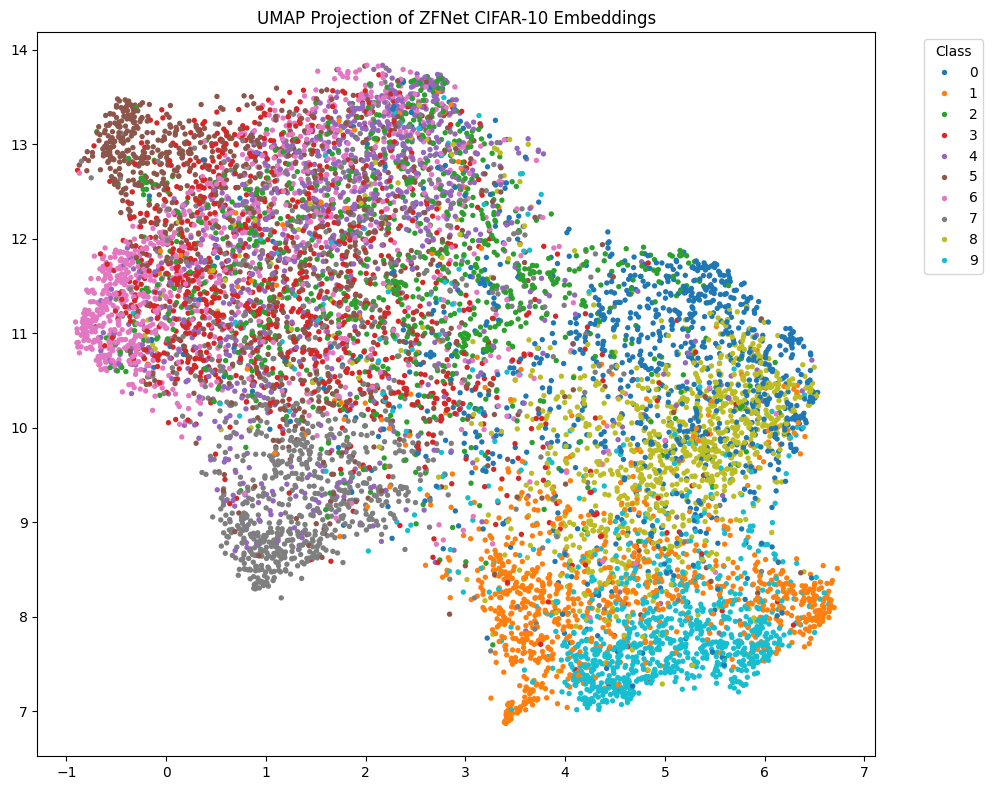

In [11]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine')
embedding_2d = reducer.fit_transform(embeddings)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=embedding_2d[:, 0], y=embedding_2d[:, 1], hue=labels, palette='tab10', s=15, linewidth=0)
plt.title("UMAP Projection of ZFNet CIFAR-10 Embeddings")
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

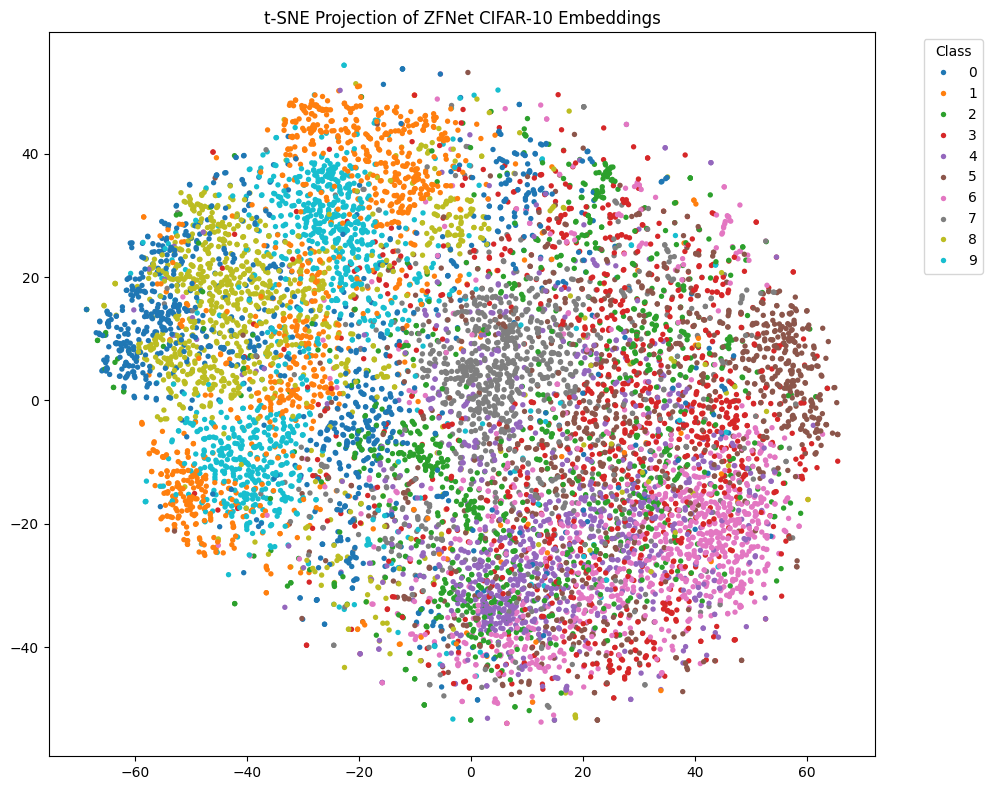

In [12]:
tsne = TSNE(n_components=2, perplexity=30, metric='cosine', n_iter=1000)
tsne_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=tsne_2d[:, 0], y=tsne_2d[:, 1], hue=labels, palette='tab10', s=15, linewidth=0)
plt.title("t-SNE Projection of ZFNet CIFAR-10 Embeddings")
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [10]:
label_to_indices = defaultdict(list)
for idx, label in enumerate(labels):
    label_to_indices[label].append(idx)

class_to_idx = {}
top_k = 10
selected_labels = list(label_to_indices.keys())[:top_k]

for label in selected_labels:
    class_to_idx[label] = random.choice(label_to_indices[label])

results = {}

for class_label, query_idx in class_to_idx.items():
    query_embedding = embeddings[query_idx].reshape(1, -1)
    similarities = cosine_similarity(query_embedding, embeddings)[0]
    similar_indices = similarities.argsort()[::-1][1:top_k+1]
    
    results[class_label] = {
        "query_idx": query_idx,
        "neighbors": similar_indices
    }

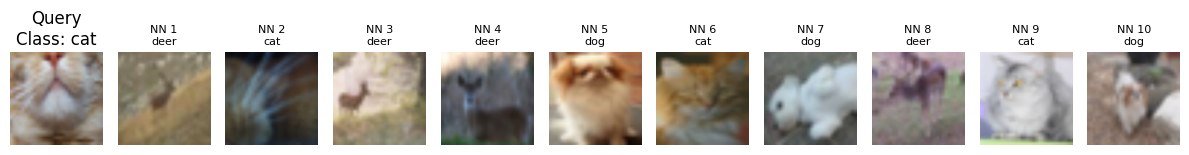

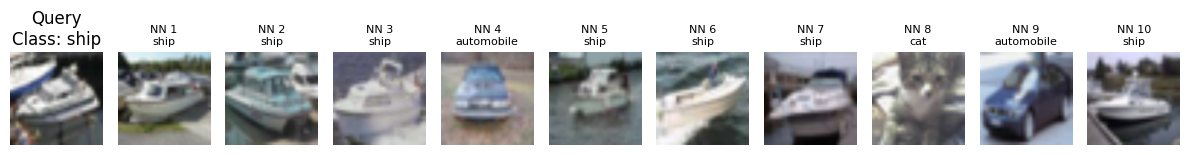

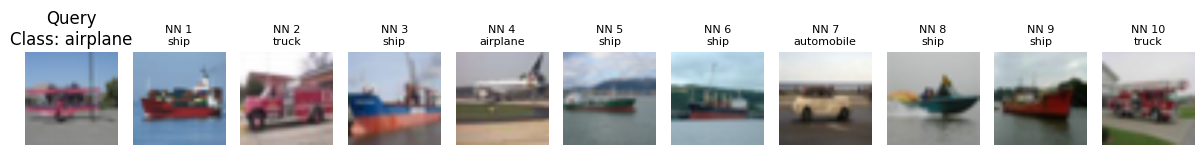

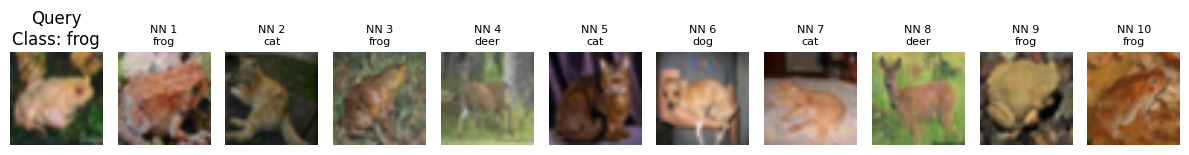

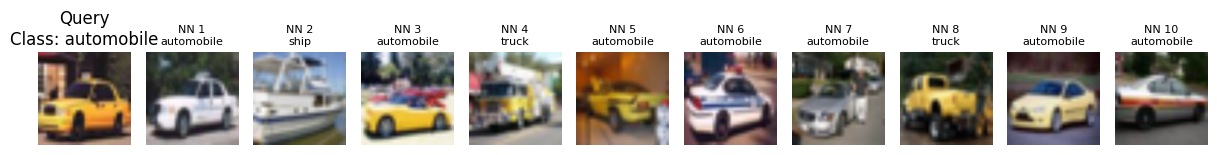

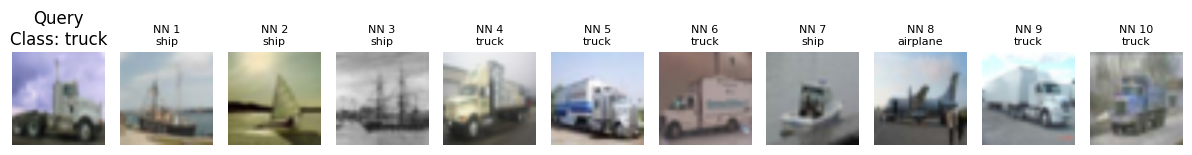

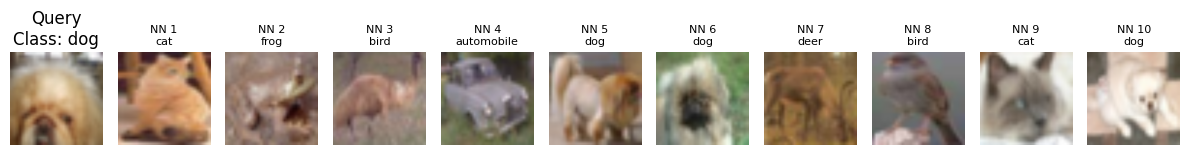

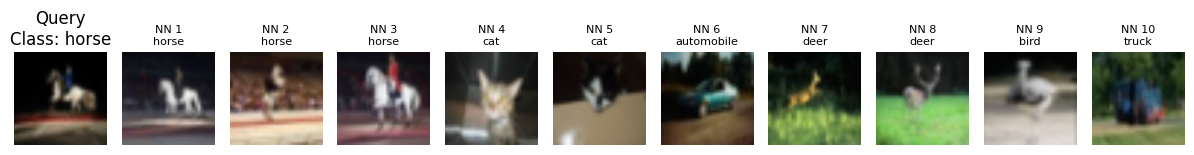

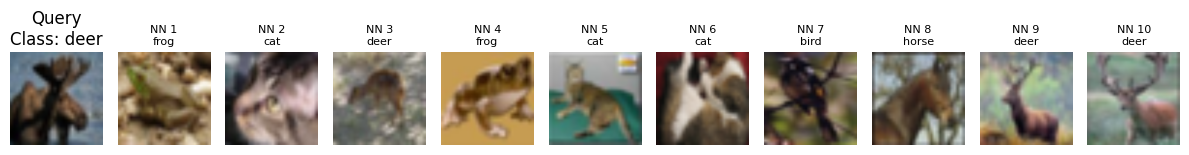

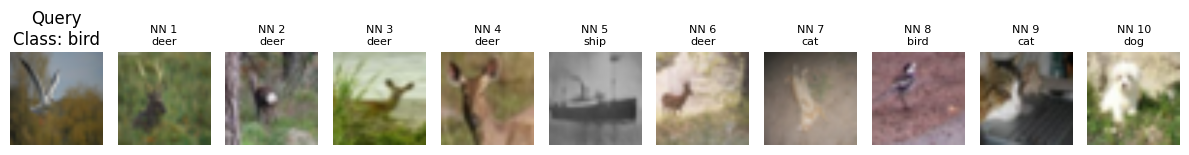

In [ ]:

def unnormalize(img_tensor):
    
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img_tensor = img_tensor.cpu() * std + mean
    img_tensor = torch.clamp(img_tensor, 0, 1)
    
    return img_tensor

def show_neighbors(dataset, query_idx, neighbor_indices, class_name):
    
    plt.figure(figsize=(12, 2))
    plt.subplot(1, top_k + 1, 1)
    query_img = unnormalize(dataset[query_idx][0])
    plt.imshow(query_img.permute(1, 2, 0).numpy())
    plt.title(f"Query\nClass: {class_name}")
    plt.axis('off')

    for i, idx in enumerate(neighbor_indices):
        plt.subplot(1, top_k + 1, i + 2)
        nn_img = unnormalize(dataset[idx][0])
        plt.imshow(nn_img.permute(1, 2, 0).numpy())
        nn_label_name = dataset.classes[dataset[idx][1]]
        plt.title(f"NN {i+1}\n{nn_label_name}", fontsize=8)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# %%
for class_label, data in results.items():
    show_neighbors(
        dataset=test_dataset,
        query_idx=data["query_idx"],
        neighbor_indices=data["neighbors"],
        class_name=test_dataset.classes[class_label]
    )


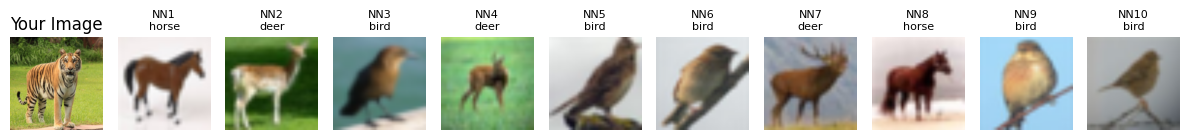

In [13]:
# %%
# External image similarity
your_image_path = "tiger.jpg"  
top_k = 10

img = Image.open(your_image_path).convert("RGB")
img_t = transform(img).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    features = model(img_t)
    features = features.view(features.size(0), -1).cpu().numpy()

all_emb = np.load("embeddings_zfnet/zfnet_cifar10_embeddings.npy")
sims = cosine_similarity(features, all_emb)[0]
neighbor_idxs = sims.argsort()[::-1][:top_k]

plt.figure(figsize=(12, 2))
plt.subplot(1, top_k+1, 1)
plt.imshow(img.resize((224,224)))
plt.title("Your Image")
plt.axis("off")

for i, idx in enumerate(neighbor_idxs):
    ds_img, ds_lbl = test_dataset[idx]
    nn_img = unnormalize(ds_img)
    plt.subplot(1, top_k+1, i+2)
    plt.imshow(nn_img.permute(1,2,0).numpy())
    plt.title(f"NN{i+1}\n{test_dataset.classes[ds_lbl]}", fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

### AlexNet Transfer Learning:

In [9]:
# Use standard AlexNet since it's available in torchvision and similar to ZFNet
model = torchvision.models.alexnet(pretrained=True)

# Freeze all feature extractor layers
for param in model.features.parameters():
    param.requires_grad = False

# Replace the classifier head for CIFAR-10 (10 classes)
model.classifier[6] = nn.Linear(4096, 10)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Define loss function and optimizer (only for classifier parameters)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# Load CIFAR-10 training set for fine-tuning
train_dataset = torchvision.datasets.CIFAR10(
    root=r'C:\Users\rafin\Desktop\465_Project\CSE465_FeatureUnderstanding\data',
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

Files already downloaded and verified


In [10]:
# Training loop
num_epochs = 10
train_losses = []
val_losses = []
val_accuracies = []

print("Training classifier head...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    scheduler.step()
    
    # Calculate validation loss and accuracy
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    epoch_train_loss = running_loss / len(train_loader)
    epoch_val_loss = val_loss / len(test_loader)
    epoch_val_acc = 100. * correct / total
    
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)
    
    print(f"Epoch {epoch+1}: Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%")

Training classifier head...


Epoch 1/10: 100%|██████████| 782/782 [01:18<00:00, 10.01it/s]


Epoch 1: Train Loss: 0.7634, Val Loss: 0.5712, Val Acc: 79.82%


Epoch 2/10: 100%|██████████| 782/782 [01:18<00:00,  9.93it/s]


Epoch 2: Train Loss: 0.5861, Val Loss: 0.4950, Val Acc: 83.27%


...

Epoch 8: Train Loss: 0.2597, Val Loss: 0.3901, Val Acc: 87.24%


Epoch 9/10: 100%|██████████| 782/782 [01:22<00:00,  9.53it/s]


Epoch 9: Train Loss: 0.2355, Val Loss: 0.4009, Val Acc: 86.97%


Epoch 10/10: 100%|██████████| 782/782 [01:18<00:00,  9.93it/s]


Epoch 10: Train Loss: 0.2221, Val Loss: 0.3952, Val Acc: 87.30%


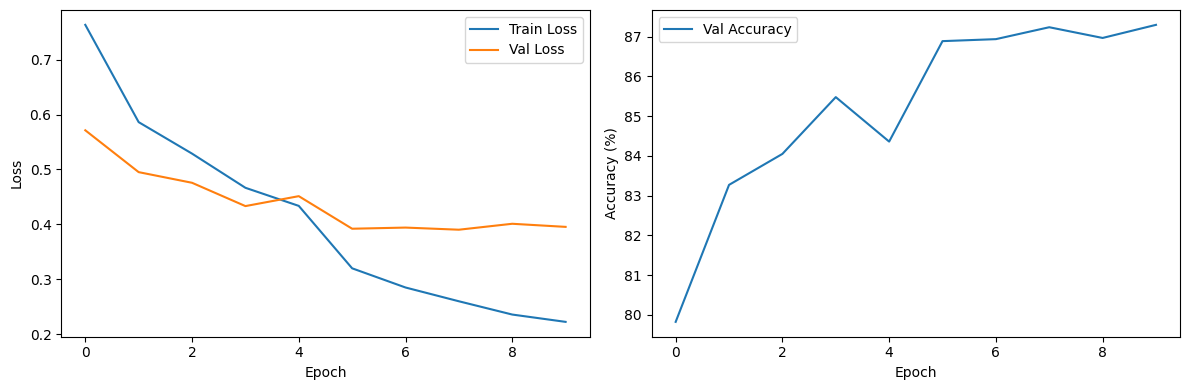

In [11]:
# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# Comprehensive evaluation on test set
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import seaborn as sns

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Evaluating"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        _, preds = outputs.max(1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Convert to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Calculate metrics
accuracy = 100.0 * np.mean(all_preds == all_labels)
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted')

print(f"\nFinal Test Accuracy: {accuracy:.2f}%")
print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"Weighted F1-Score: {f1:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))

Evaluating: 100%|██████████| 157/157 [00:12<00:00, 12.60it/s]


Final Test Accuracy: 87.30%
Weighted Precision: 0.8747
Weighted Recall: 0.8730
Weighted F1-Score: 0.8735

Classification Report:
              precision    recall  f1-score   support

    airplane       0.87      0.89      0.88      1000
  automobile       0.92      0.93      0.92      1000
        bird       0.89      0.82      0.85      1000
         cat       0.73      0.78      0.76      1000
        deer       0.85      0.86      0.85      1000
         dog       0.81      0.83      0.82      1000
        frog       0.90      0.90      0.90      1000
       horse       0.92      0.89      0.90      1000
        ship       0.94      0.91      0.92      1000
       truck       0.92      0.92      0.92      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



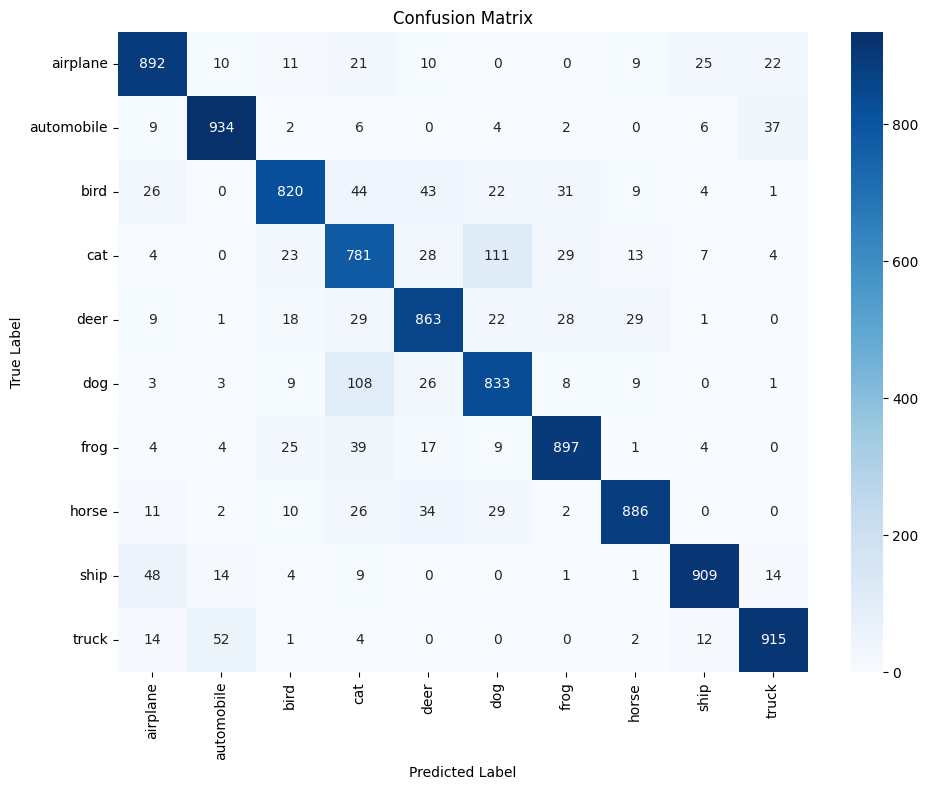

In [13]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=test_dataset.classes, 
            yticklabels=test_dataset.classes)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

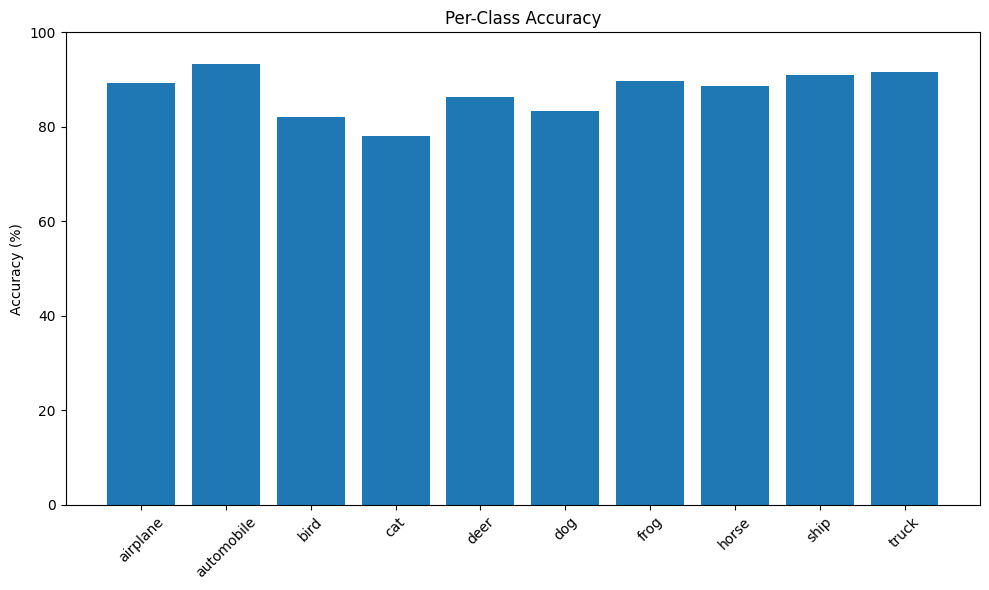

In [14]:
# Per-class accuracy
class_correct = np.zeros(10)
class_total = np.zeros(10)
for i in range(10):
    idx = all_labels == i
    class_correct[i] = np.sum(all_preds[idx] == i)
    class_total[i] = np.sum(idx)

class_accuracies = 100 * class_correct / class_total

plt.figure(figsize=(10, 6))
plt.bar(range(10), class_accuracies)
plt.xticks(range(10), test_dataset.classes, rotation=45)
plt.title('Per-Class Accuracy')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

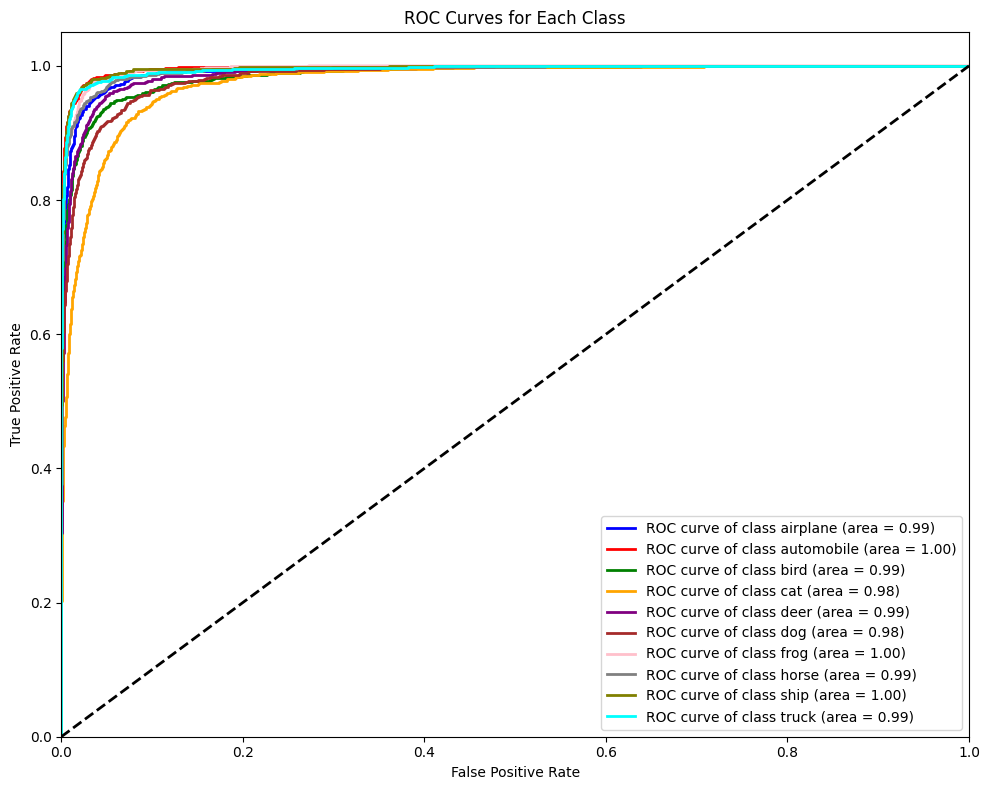

In [15]:
# ROC Curve (for binary classification we'd use this, for multi-class we need to adapt)
# For multi-class, we can show ROC for each class vs rest
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the output for multi-class ROC
y_test_bin = label_binarize(all_labels, classes=range(10))
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(10):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']
for i, color in zip(range(10), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(test_dataset.classes[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Each Class')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [16]:

# Print final summary
print("\n=== TRANSFER LEARNING EVALUATION SUMMARY ===")
print(f"Test Accuracy: {accuracy:.2f}%")
print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"Weighted F1-Score: {f1:.4f}")
print(f"Mean ROC AUC: {np.mean(list(roc_auc.values())):.4f}")


=== TRANSFER LEARNING EVALUATION SUMMARY ===
Test Accuracy: 87.30%
Weighted Precision: 0.8747
Weighted Recall: 0.8730
Weighted F1-Score: 0.8735
Mean ROC AUC: 0.9905
